# Filtro IIR Butterworth Simple para ECG
## Remover Baseline Wandering - Versión Simplificada

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import scipy.io.wavfile as wavfile
import os

print("✓ Librerías importadas")

✓ Librerías importadas



SEÑAL ECG ORIGINAL
Frecuencia de muestreo: 250 Hz
Duración: 10.00 segundos
Muestras: 2500
Rango: [-15898, 32767]
Media: 2997.07


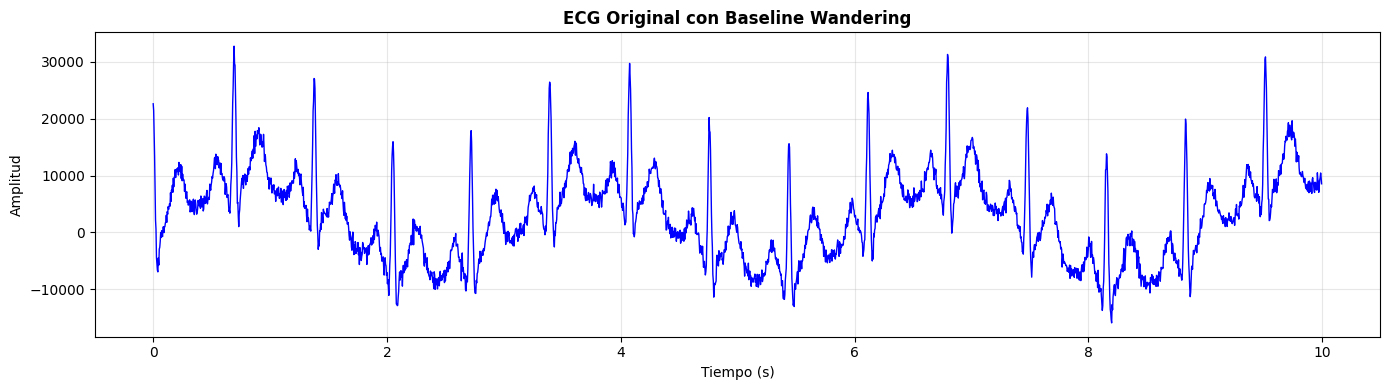

In [2]:
# 1. CARGAR SEÑAL ECG
signals_path = os.path.join(os.getcwd(), 'signals', 'ecg_signal.wav')
fs, ecg_signal = wavfile.read(signals_path)

n_samples = len(ecg_signal)
duration = n_samples / fs
time = np.arange(n_samples) / fs

print(f"\n{'='*50}")
print("SEÑAL ECG ORIGINAL")
print(f"{'='*50}")
print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Duración: {duration:.2f} segundos")
print(f"Muestras: {n_samples}")
print(f"Rango: [{np.min(ecg_signal)}, {np.max(ecg_signal)}]")
print(f"Media: {np.mean(ecg_signal):.2f}")

# Graficar
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time, ecg_signal, 'b-', linewidth=1)
ax.set_title('ECG Original con Baseline Wandering', fontsize=12, fontweight='bold')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Amplitud')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
# 2. DISEÑAR FILTRO IIR BUTTERWORTH
cutoff_freq = 0.5  # Hz - eliminar wandering < 0.5 Hz
nyquist = fs / 2
normalized_cutoff = cutoff_freq / nyquist

# Crear filtro orden 4
sos = signal.butter(4, normalized_cutoff, btype='high', output='sos')

print(f"\n{'='*50}")
print("FILTRO IIR BUTTERWORTH")
print(f"{'='*50}")
print(f"Tipo: Paso Alto (High-Pass)")
print(f"Orden: 4")
print(f"Cutoff: {cutoff_freq} Hz")
print(f"Cutoff Normalizado: {normalized_cutoff:.6f}")
print(f"✓ Filtro diseñado exitosamente")


FILTRO IIR BUTTERWORTH
Tipo: Paso Alto (High-Pass)
Orden: 4
Cutoff: 0.5 Hz
Cutoff Normalizado: 0.004000
✓ Filtro diseñado exitosamente



RESULTADOS DEL FILTRADO
Señal filtrada - Min: -13334, Max: 23570
Baseline removido - Min: -9438.58, Max: 15941.18
Energía removida: 133216531998


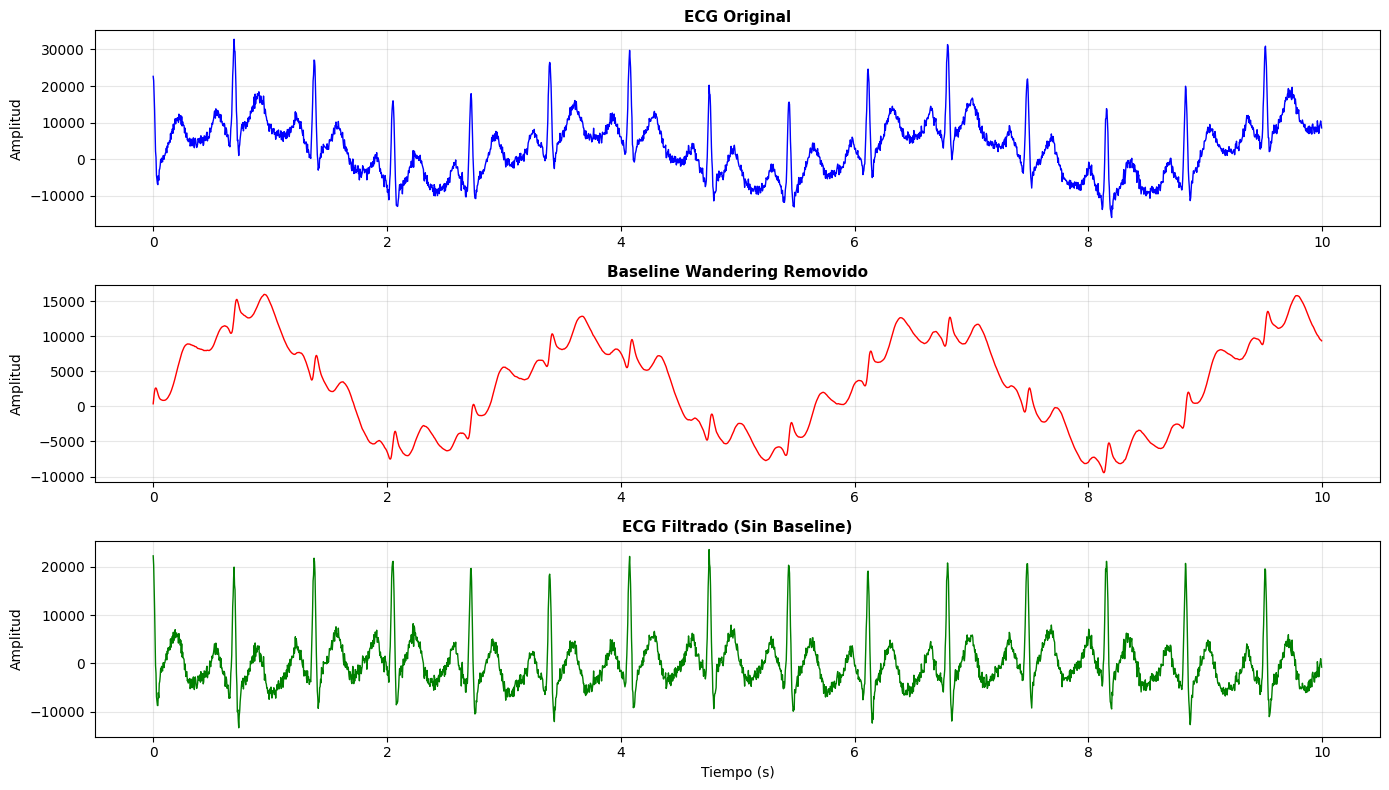

In [4]:
# 3. APLICAR FILTRO
ecg_filtered = signal.sosfilt(sos, ecg_signal)
# Aplicar dos veces para mejor fase
#ecg_filtered = signal.sosfilt(sos, ecg_filtered[::-1])[::-1]

# Baseline wandering removido
baseline = ecg_signal - ecg_filtered

print(f"\n{'='*50}")
print("RESULTADOS DEL FILTRADO")
print(f"{'='*50}")
print(f"Señal filtrada - Min: {np.min(ecg_filtered):.0f}, Max: {np.max(ecg_filtered):.0f}")
print(f"Baseline removido - Min: {np.min(baseline):.2f}, Max: {np.max(baseline):.2f}")
print(f"Energía removida: {np.sum(baseline**2):.0f}")

# Graficar comparación
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Original
axes[0].plot(time, ecg_signal, 'b-', linewidth=1)
axes[0].set_title('ECG Original', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

# Baseline
axes[1].plot(time, baseline, 'r-', linewidth=1)
axes[1].set_title('Baseline Wandering Removido', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Amplitud')
axes[1].grid(True, alpha=0.3)

# Filtrado
axes[2].plot(time, ecg_filtered, 'g-', linewidth=1)
axes[2].set_title('ECG Filtrado (Sin Baseline)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Tiempo (s)')
axes[2].set_ylabel('Amplitud')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


ANÁLISIS DE POLOS Y CEROS
Polos dentro unitario: 4 / 4
Estado: ✓ ESTABLE


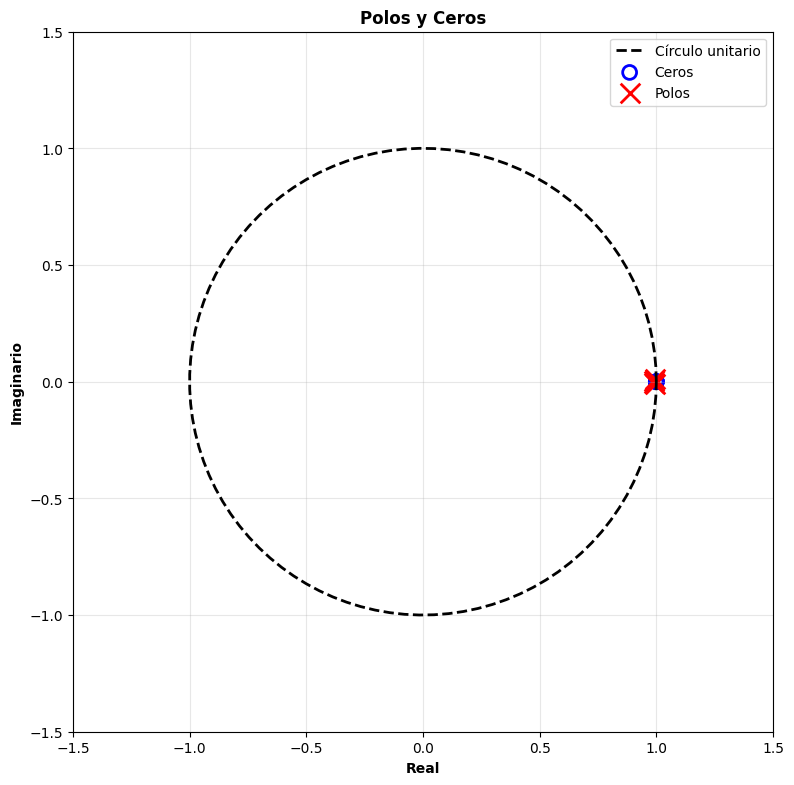

In [5]:
# 4. ANÁLISIS DE ESTABILIDAD
b, a = signal.sos2tf(sos)
z = np.roots(b)
p = np.roots(a)

polos_estables = np.sum(np.abs(p) < 1)

print(f"\n{'='*50}")
print("ANÁLISIS DE POLOS Y CEROS")
print(f"{'='*50}")
print(f"Polos dentro unitario: {polos_estables} / {len(p)}")
print(f"Estado: {'✓ ESTABLE' if polos_estables == len(p) else '✗ INESTABLE'}")

# Gráfica
fig, ax = plt.subplots(figsize=(8, 8))
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=2, label='Círculo unitario')
ax.scatter(np.real(z), np.imag(z), s=100, marker='o', facecolors='none', 
          edgecolors='blue', linewidth=2, label='Ceros')
ax.scatter(np.real(p), np.imag(p), s=200, marker='x', c='red', linewidth=2, label='Polos')
ax.set_xlabel('Real', fontweight='bold')
ax.set_ylabel('Imaginario', fontweight='bold')
ax.set_title('Polos y Ceros', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_aspect('equal')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
plt.tight_layout()
plt.show()

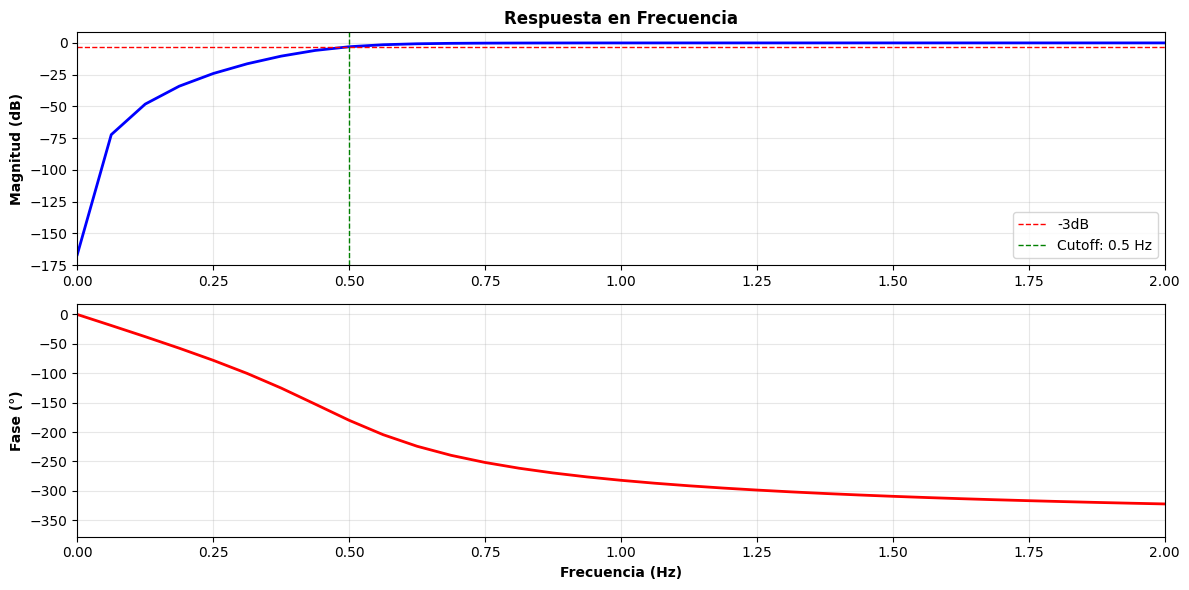

In [6]:
# 5. RESPUESTA EN FRECUENCIA
w, H = signal.freqz(b, a, worN=2000, fs=fs)
magnitude_db = 20 * np.log10(np.abs(H) + 1e-10)
phase = np.unwrap(np.angle(H)) * 180 / np.pi

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Magnitud
ax1.plot(w, magnitude_db, 'b-', linewidth=2)
ax1.axhline(-3, color='r', linestyle='--', linewidth=1, label='-3dB')
ax1.axvline(cutoff_freq, color='g', linestyle='--', linewidth=1, label=f'Cutoff: {cutoff_freq} Hz')
ax1.set_ylabel('Magnitud (dB)', fontweight='bold')
ax1.set_title('Respuesta en Frecuencia', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim(0, 2)

# Fase
ax2.plot(w, phase, 'r-', linewidth=2)
ax2.set_xlabel('Frecuencia (Hz)', fontweight='bold')
ax2.set_ylabel('Fase (°)', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 2)

plt.tight_layout()
plt.show()

In [7]:
# 6. EXTRAER COEFICIENTES PARA ARDUINO
print(f"\n{'='*60}")
print("COEFICIENTES ARDUINO - FORMATO Q15 (16 bits)")
print(f"{'='*60}\n")

# Normalizar SOS por a0
sos_norm = sos.copy()
for i in range(len(sos_norm)):
    a0 = sos_norm[i, 3]
    sos_norm[i] = sos_norm[i] / a0

# Convertir a Q15 (multiplicar por 2^15)
SCALE = 2**15
coeffs_arduino = []

print("// COEFICIENTES DEL FILTRO IIR para Arduino")
print("// Formato: Q15 fixed-point (16-bit integers)\n")

for section in range(len(sos_norm)):
    b0 = int(round(sos_norm[section, 0] * SCALE))
    b1 = int(round(sos_norm[section, 1] * SCALE))
    b2 = int(round(sos_norm[section, 2] * SCALE))
    a1 = int(round(sos_norm[section, 4] * SCALE))
    a2 = int(round(sos_norm[section, 5] * SCALE))
    
    print(f"// SECCIÓN {section+1}")
    print(f"#define b0_s{section+1} {b0:7d}  // {sos_norm[section, 0]:+.10f}")
    print(f"#define b1_s{section+1} {b1:7d}  // {sos_norm[section, 1]:+.10f}")
    print(f"#define b2_s{section+1} {b2:7d}  // {sos_norm[section, 2]:+.10f}")
    print(f"#define a1_s{section+1} {a1:7d}  // {sos_norm[section, 4]:+.10f}")
    print(f"#define a2_s{section+1} {a2:7d}  // {sos_norm[section, 5]:+.10f}\n")
    
    coeffs_arduino.append({'b0': b0, 'b1': b1, 'b2': b2, 'a1': a1, 'a2': a2})

print("\n// Variables globales de estado")
print("int32_t x1_s1=0, x2_s1=0, y1_s1=0, y2_s1=0;  // Sección 1")
print("int32_t x1_s2=0, x2_s2=0, y1_s2=0, y2_s2=0;  // Sección 2")


COEFICIENTES ARDUINO - FORMATO Q15 (16 bits)

// COEFICIENTES DEL FILTRO IIR para Arduino
// Formato: Q15 fixed-point (16-bit integers)

// SECCIÓN 1
#define b0_s1   32234  // +0.9837151741
#define b1_s1  -64469  // -1.9674303483
#define b2_s1   32234  // +0.9837151741
#define a1_s1  -64779  // -1.9768913543
#define a2_s1   32016  // +0.9770474536

// SECCIÓN 2
#define b0_s2   32768  // +1.0000000000
#define b1_s2  -65536  // -2.0000000000
#define b2_s2   32768  // +1.0000000000
#define a1_s2  -65217  // -1.9902712417
#define a2_s2   32454  // +0.9904283975


// Variables globales de estado
int32_t x1_s1=0, x2_s1=0, y1_s1=0, y2_s1=0;  // Sección 1
int32_t x1_s2=0, x2_s2=0, y1_s2=0, y2_s2=0;  // Sección 2


In [8]:
# 7. CÓDIGO ARDUINO COMPLETO
print("\n" + "="*70)
print("CODIGO ARDUINO - COPIA EN arduino_iir_simple.ino")
print("="*70 + "\n")

print("// COEFICIENTES GENERADOS:")
for i, coef in enumerate(coeffs_arduino):
    print(f"// SECCIÓN {i+1}")
    print(f"int16_t b0_s{i+1} = {coef['b0']:7d};  // {sos_norm[i,0]:+.10f}")
    print(f"int16_t b1_s{i+1} = {coef['b1']:7d};  // {sos_norm[i,1]:+.10f}")
    print(f"int16_t b2_s{i+1} = {coef['b2']:7d};  // {sos_norm[i,2]:+.10f}")
    print(f"int16_t a1_s{i+1} = {coef['a1']:7d};  // {sos_norm[i,4]:+.10f}")
    print(f"int16_t a2_s{i+1} = {coef['a2']:7d};  // {sos_norm[i,5]:+.10f}\n")

print("\n✓ Ver archivo: arduino_iir_simple.ino")
print("✓ Copiar coeficientes en las líneas 23-46")


CODIGO ARDUINO - COPIA EN arduino_iir_simple.ino

// COEFICIENTES GENERADOS:
// SECCIÓN 1
int16_t b0_s1 =   32234;  // +0.9837151741
int16_t b1_s1 =  -64469;  // -1.9674303483
int16_t b2_s1 =   32234;  // +0.9837151741
int16_t a1_s1 =  -64779;  // -1.9768913543
int16_t a2_s1 =   32016;  // +0.9770474536

// SECCIÓN 2
int16_t b0_s2 =   32768;  // +1.0000000000
int16_t b1_s2 =  -65536;  // -2.0000000000
int16_t b2_s2 =   32768;  // +1.0000000000
int16_t a1_s2 =  -65217;  // -1.9902712417
int16_t a2_s2 =   32454;  // +0.9904283975


✓ Ver archivo: arduino_iir_simple.ino
✓ Copiar coeficientes en las líneas 23-46
